In [1]:
# ======================================================
# Project 02 - Customer Churn Analysis
# Author: Martin Panelo
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization style
plt.style.use("ggplot")
sns.set_palette("Blues")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#Cuantas celdas y columnas tenemos 
df.shape

(7043, 21)

In [4]:
#Revisar tipos de datos, valores nulo, memoria utilizada, si alguna columna esta mal importada

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#Genera estadisticas descriptivas de todas las variables numericas y categoricas del dataset, como la media, mediana, desviacion estandar, valores minimos y maximos, entre otros.

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Data Quality Check:
# TotalCharges was imported as an object instead of a numeric column.
# Let's verify if the column contains blank spaces.

(df["TotalCharges"] == " ").sum()

11

In [7]:
# TotalCharges contains 11 blank values stored as empty spaces.
# Convert the column to numeric and replace invalid values with NaN.

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
# All missing TotalCharges values belong to customers with tenure = 0.
# These customers have not completed their first billing cycle yet.
# Since they represent only 11 observations (0.16% of the dataset),
# we will remove them from the analysis.

df = df.dropna()
df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


# Exploratory Data Analysis (EDA)

In this section, we explore customer behavior and identify the main factors associated with customer churn through descriptive statistics and data visualization.

## 🎯 Target Variable Analysis

First, let's understand the distribution of the target variable (Churn). This helps identify whether customer attrition is balanced or imbalanced before exploring the factors associated with it.

In [11]:
# Number of customers by churn status

df["Churn"].value_counts()

No     5163
Yes    1869
Name: Churn, dtype: int64

In [12]:
# Percentage of customers by churn status

round(df["Churn"].value_counts(normalize=True) * 100, 2)

No     73.42
Yes    26.58
Name: Churn, dtype: float64

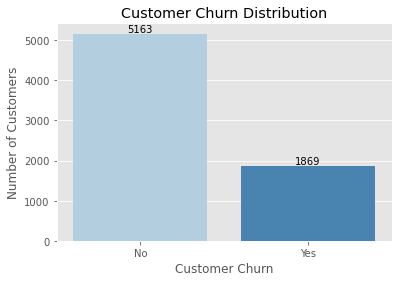

In [13]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Churn",
    palette="Blues"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Churn")
plt.ylabel("Number of Customers")

# Add count labels above each bar
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

### 📌 Business Insight

- Approximately **73.4%** of customers remained with the company, while **26.6%** churned.
- The dataset is moderately imbalanced, with non-churn customers representing the majority.
- This indicates that customer retention is generally strong, although more than one out of four customers left the company, making churn prediction a valuable business problem.

## 📄 Contract Type vs Customer Churn

Contract duration is expected to influence customer retention. Let's analyze whether customers with month-to-month contracts are more likely to churn than those with longer-term contracts.

In [14]:
# Number of customers by contract type

df["Contract"].value_counts()

Month-to-month    3875
Two year          1685
One year          1472
Name: Contract, dtype: int64

In [15]:
# Churn distribution by contract type

pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


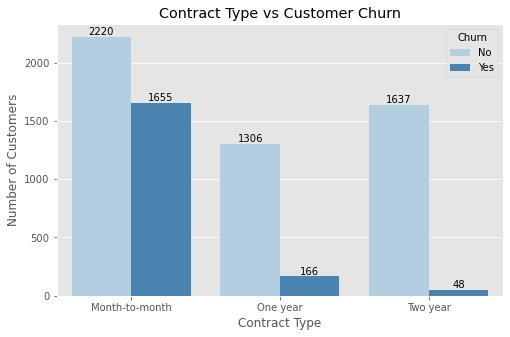

In [16]:
plt.figure(figsize=(8,5))


ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Blues"
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )
plt.legend(title="Churn")

plt.show()

### 📌 Business Insight

- Customers with month-to-month contracts show the highest churn rate (42.7%).
- Customers with one-year and two-year contracts are significantly more likely to stay.
- Longer contract commitments appear to be strongly associated with customer retention.
- Contract type appears to be one of the strongest predictors of customer churn.

# ⏳ Customer Tenure Analysis

Customer tenure represents the number of months a customer has stayed with the company.

Longer relationships are generally associated with higher customer loyalty. Let's explore whether customer churn is concentrated among newer customers.

In [17]:
# Summary statistics for customer tenure

df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

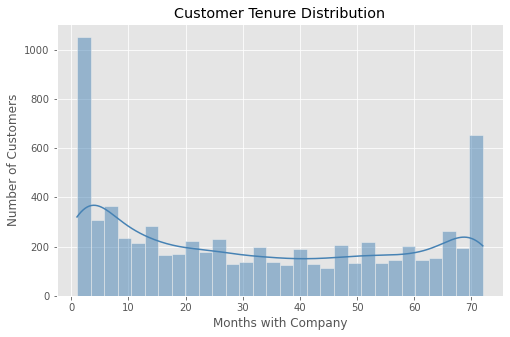

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Months with Company")
plt.ylabel("Number of Customers")

plt.show()

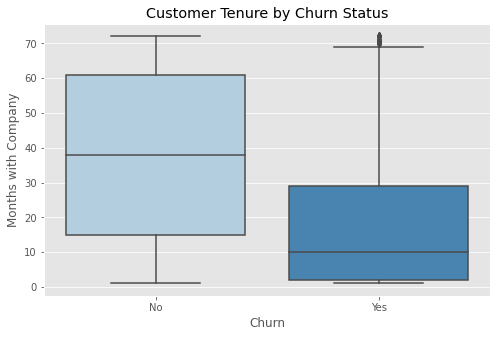

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    palette="Blues"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Months with Company")

plt.show()

### 📌 Business Insight

- Customers who churn tend to have significantly lower tenure than customers who stay.
- The median tenure for churned customers is much lower, suggesting that customer loss is concentrated among newer customers.
- Customers with longer tenure appear to be more loyal and less likely to leave the company.
- This indicates that early customer experience may be critical for improving retention.

# 💰 Monthly Charges Analysis

Monthly charges represent the amount each customer pays every month.

Pricing is often one of the main drivers of customer decisions. Let's investigate whether customers with higher monthly charges are more likely to churn.

In [20]:
# Summary statistics for monthly charges

df["MonthlyCharges"].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

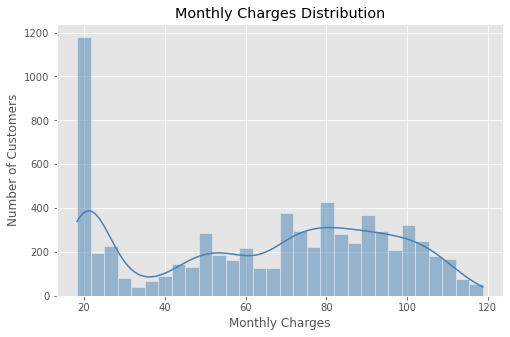

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

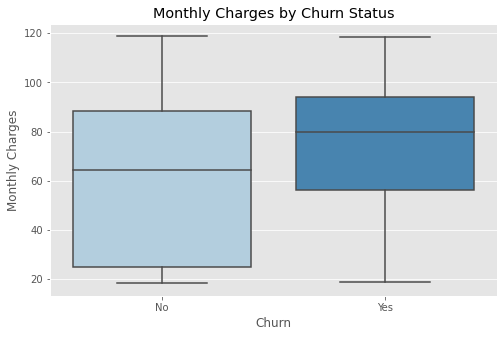

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="Blues"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## 📌 Business Insight

- Customers who churn generally have higher monthly charges than those who stay.
- The median monthly payment is noticeably higher among churned customers.
- This suggests that pricing or premium service plans may contribute to customer attrition.
- Monthly charges appear to be another strong predictor of customer churn.

# 🌐 Internet Service Analysis

Internet service is one of the company's core products.

Different internet technologies may provide different customer experiences and pricing levels. Let's investigate whether churn varies across internet service types.

In [23]:
# Number of customers by internet service type

df["InternetService"].value_counts()

Fiber optic    3096
DSL            2416
No             1520
Name: InternetService, dtype: int64

In [24]:
# Churn percentage by internet service

pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


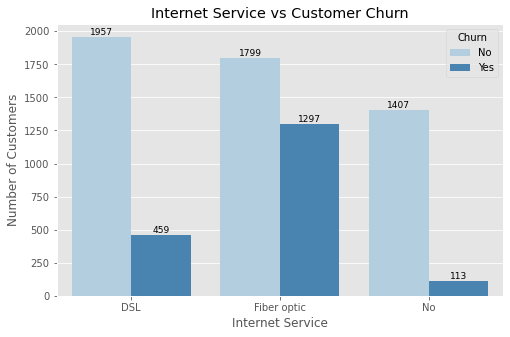

In [25]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="Blues"
)

plt.title("Internet Service vs Customer Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

## 📌 Business Insight

- Customers with Fiber optic internet show the highest churn rate (41.9%).
- DSL customers are considerably more likely to remain with the company (81.0% retention).
- Customers without internet service rarely churn (only 7.4%).
- This suggests that factors related to the Fiber optic service (pricing, competition, customer expectations, or service quality) may deserve further investigation.

# 🔒 Online Security Analysis

Online Security is an additional service designed to protect customers while using the internet.

Let's explore whether customers who subscribe to this service are less likely to churn.

In [26]:
df["OnlineSecurity"].value_counts()

No                     3497
Yes                    2015
No internet service    1520
Name: OnlineSecurity, dtype: int64

In [27]:
pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


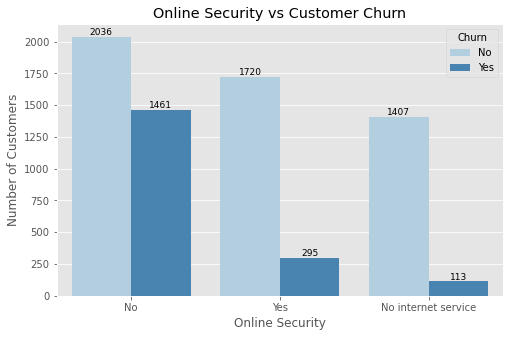

In [28]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn",
    palette="Blues"
)

plt.title("Online Security vs Customer Churn")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

### 📌 Business Insight

- Customers without Online Security show a much higher churn rate (41.8%).
- Customers with Online Security are significantly more likely to stay, with only 14.6% churn.
- This suggests that additional protection services may increase customer retention.
- Online Security appears to be an important factor associated with customer loyalty.

# 🛠️ Tech Support Analysis

Tech Support may influence customer satisfaction and retention.

Let's analyze whether customers with technical support are less likely to churn.

In [29]:
df["TechSupport"].value_counts()


No                     3472
Yes                    2040
No internet service    1520
Name: TechSupport, dtype: int64

In [30]:
pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


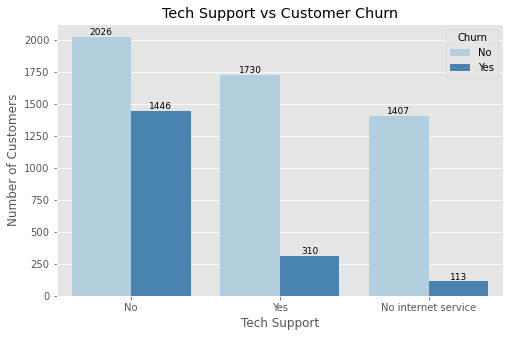

In [31]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn",
    palette="Blues"
)

plt.title("Tech Support vs Customer Churn")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

### 📌 Business Insight

- Customers without Tech Support have the highest churn rate (41.6%).
- Customers who subscribe to Tech Support are much more likely to stay, with only 15.2% churn.
- Customers without internet service show the lowest churn rate (7.4%).
- Tech Support appears to be another strong factor associated with customer retention.

# 💳 Payment Method Analysis

Payment methods may influence customer retention due to convenience or billing experience.

Let's analyze whether churn differs across payment methods.

In [32]:
df["PaymentMethod"].value_counts()

Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: PaymentMethod, dtype: int64

In [33]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


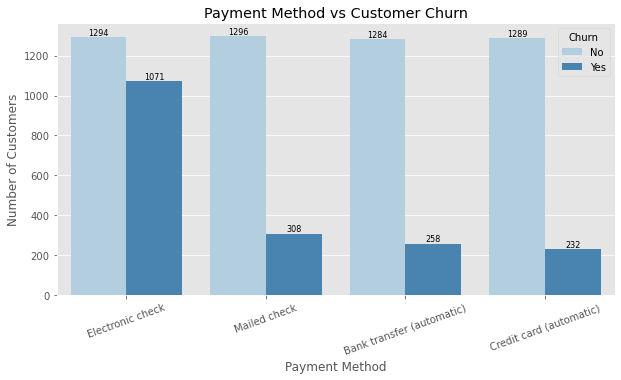

In [34]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    palette="Blues"
)

plt.title("Payment Method vs Customer Churn")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.show()

### 📌 Business Insight

- Customers using Electronic Check have the highest churn rate (45.3%).
- Automatic payment methods (Credit Card and Bank Transfer) are associated with much lower churn rates (around 15–17%).
- Customers paying by Mailed Check also show relatively low churn (19.2%).
- Encouraging customers to adopt automatic payment methods could help improve customer retention.

# 👴 Senior Citizen Analysis

Let's investigate whether senior customers show different churn behavior compared to non-senior customers.

In [35]:
df["SeniorCitizen"].value_counts()

0    5890
1    1142
Name: SeniorCitizen, dtype: int64

In [36]:
pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


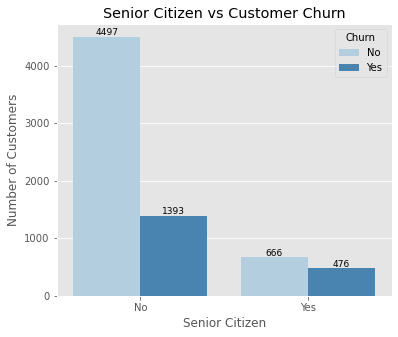

In [37]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn",
    palette="Blues"
)

plt.title("Senior Citizen vs Customer Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.xticks([0,1], ["No","Yes"])

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2,
         p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.show()

### 📌 Business Insight

- Senior customers have a significantly higher churn rate (41.7%) than non-senior customers (23.7%).
- Although senior citizens represent a smaller portion of the customer base, they are substantially more likely to leave the company.
- This suggests that age may play an important role in customer retention strategies.

# ✅ Exploratory Data Analysis Summary

The exploratory analysis identified several variables strongly associated with customer churn.

The most influential factors appear to be:

- Contract type
- Customer tenure
- Monthly charges
- Internet service
- Online Security
- Tech Support
- Payment method
- Senior citizen status

These findings will guide the next stage of the project, where we will prepare the data and build a Machine Learning model to predict customer churn.

# 🤖 Data Preparation for Machine Learning

Before training a machine learning model, we need to prepare the dataset.

This includes:

- Removing unnecessary columns.
- Encoding categorical variables.
- Splitting features and target variable.
- Creating training and testing datasets.

In [38]:
# Remove customer identifier

df = df.drop(columns="customerID")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
# Convert target variable to binary because the target variable is binary, and machine learning classification algorithms require numerical labels. Mapping No to 0 and Yes to 1 follows the standard convention used by scikit-learn and simplifies model training and evaluation.

df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

df["Churn"].value_counts()

0    5163
1    1869
Name: Churn, dtype: int64

In [40]:
# One-Hot Encode categorical variables

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [41]:
# One-Hot Encode categorical variables

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [42]:
df_encoded.shape

(7032, 31)

In [43]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   uint8  
 6   Partner_Yes                            7032 non-null   uint8  
 7   Dependents_Yes                         7032 non-null   uint8  
 8   PhoneService_Yes                       7032 non-null   uint8  
 9   MultipleLines_No phone service         7032 non-null   uint8  
 10  MultipleLines_Yes                      7032 non-null   uint8  
 11  Inte

### 💡 Business Insight

All categorical variables have been converted into numerical features using One-Hot Encoding.

Using `drop_first=True` removes one category from each feature, preventing redundant information (dummy variable trap) while preserving all predictive information required by the machine learning model.

# 🚂 Train-Test Split

Before training the model, we split the dataset into:

- Training set (80%) to train the model.
- Testing set (20%) to evaluate its performance on unseen data.

This helps us estimate how well the model generalizes to new customers.

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
# Features (X) and Target (y)

X = df_encoded.drop(columns="Churn")

y = df_encoded["Churn"]

In [46]:
X.shape, y.shape

((7032, 30), (7032,))

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [48]:
df_encoded.isna().sum()[df_encoded.isna().sum() > 0]

Series([], dtype: int64)

# 🤖 Logistic Regression (Baseline Model)

Logistic Regression is a simple and widely used classification algorithm.

It will serve as our baseline model for predicting customer churn before comparing it with more advanced machine learning algorithms.

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
log_model = LogisticRegression(max_iter=1000)

In [51]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [52]:
y_pred = log_model.predict(X_test)

In [ ]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [58]:
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7989


In [54]:
# Calculate precision, recall and F1-score
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

Precision: 0.6366
Recall:    0.5668
F1 Score:  0.5997


In [55]:
# Display detailed classification metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [56]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

cm

array([[912, 121],
       [162, 212]], dtype=int64)

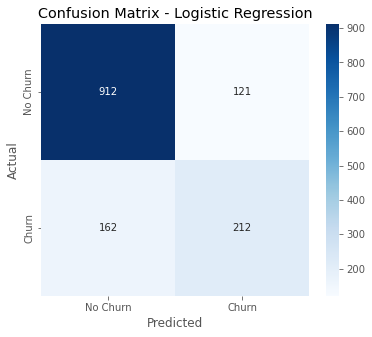

In [57]:
# Visualize confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 📌 Business Insight

- Logistic Regression achieved approximately **80% accuracy**, providing a solid baseline model.
- The model correctly identifies most customers who stay with the company.
- However, it detects only **56.7%** of actual churn cases, leaving room for improvement.
- A more advanced algorithm such as Random Forest may improve recall and overall predictive performance.

## 📈 ROC Curve and AUC Score

The ROC Curve evaluates the model's ability to distinguish between customers who churn and those who remain.

The Area Under the Curve (AUC) summarizes this performance into a single value between 0 and 1, where higher values indicate better classification performance.

In [59]:
# Import ROC curve metrics
from sklearn.metrics import roc_curve, roc_auc_score

In [60]:
# Predict churn probabilities
y_prob = log_model.predict_proba(X_test)[:, 1]

In [61]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [62]:
# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.8361


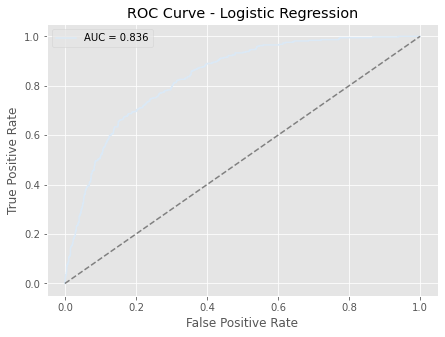

In [63]:
# Plot ROC curve
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

## 📌 Business Insight

- The Logistic Regression baseline model achieved an **AUC of 0.836**, indicating good discriminatory power.
- Overall accuracy reached approximately **80%**, making it a solid baseline for churn prediction.
- Although the model performs well overall, recall remains moderate, meaning some churning customers are still missed.
- More advanced models, such as Random Forest, may improve customer churn detection.

# 🌳 Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

We will compare its performance with the Logistic Regression baseline model.

In [64]:
# Import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

In [65]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [66]:
# Train Random Forest model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [67]:
# Generate predictions
rf_pred = rf_model.predict(X_test)

In [68]:
# Calculate model accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Accuracy: {rf_accuracy:.4f}")

Accuracy: 0.7896


In [69]:
# Calculate precision, recall and F1-score
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred):.4f}")

Precision: 0.6258
Recall:    0.5187
F1 Score:  0.5673


In [70]:
# Display detailed classification metrics
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [71]:
# Generate confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)

rf_cm

array([[917, 116],
       [180, 194]], dtype=int64)

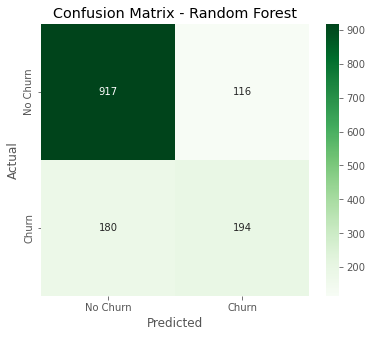

In [72]:
# Visualize confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [73]:
# Predict churn probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [74]:
# Calculate ROC curve
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_prob)

In [75]:
# Calculate AUC score
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"AUC Score: {rf_auc:.4f}")

AUC Score: 0.8165


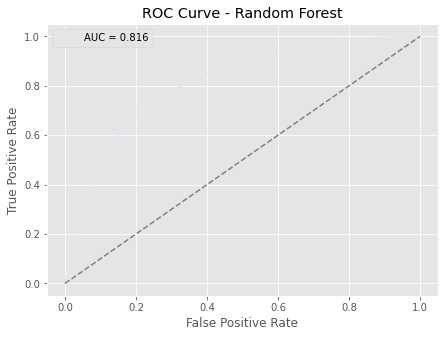

In [76]:
# Plot ROC curve
plt.figure(figsize=(7,5))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"AUC = {rf_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

I started with a Logistic Regression baseline and compared it against a Random Forest. Surprisingly, the baseline performed slightly better, showing that simpler models can outperform more complex ones depending on the dataset.

# ⭐ Feature Importance

Random Forest allows us to estimate how important each feature was during the prediction process.

This helps identify the variables that contribute the most to customer churn.

In [77]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.191435
1,tenure,0.171020
2,MonthlyCharges,0.168400
10,InternetService_Fiber optic,0.039481
28,PaymentMethod_Electronic check,0.037416
25,Contract_Two year,0.030529
4,gender_Male,0.029332
13,OnlineSecurity_Yes,0.028157
26,PaperlessBilling_Yes,0.025536
19,TechSupport_Yes,0.024114


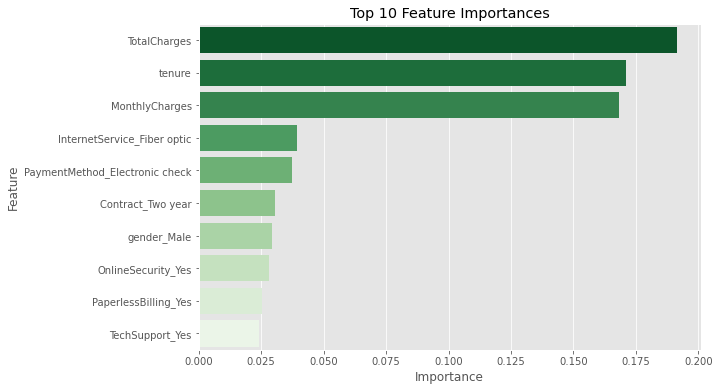

In [78]:
# Plot top 10 most important features

plt.figure(figsize=(9,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="Greens_r"
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# 📊 Model Comparison

We trained two machine learning models:

- Logistic Regression (baseline)
- Random Forest Classifier

The following table summarizes their performance.

In [79]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "AUC": [
        auc_score,
        rf_auc
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.799,0.637,0.567,0.600,0.836
1,Random Forest,0.790,0.626,0.519,0.567,0.816


# 💼 Business Conclusions

The analysis identified several important drivers of customer churn.

Key findings include:

- Customers with month-to-month contracts are much more likely to leave.
- Short-tenure customers have the highest churn risk.
- Higher monthly charges are associated with increased churn.
- Fiber optic customers churn more frequently than DSL customers.
- Customers without Online Security and Tech Support are more likely to leave.
- Automatic payment methods are associated with lower churn.
- Senior citizens present higher churn rates.

Although Random Forest was expected to outperform Logistic Regression, the baseline Logistic Regression model achieved slightly better overall performance on this dataset.

These insights can help the company improve customer retention strategies by focusing on high-risk customer segments.

# 🚀 Next Steps

Possible improvements for future work include:

- Hyperparameter tuning using GridSearchCV.
- Cross-validation.
- Feature selection techniques.
- Trying additional algorithms such as XGBoost or LightGBM.
- Building an interactive Power BI dashboard.
- Deploying the model as a web application.

# 📈 Model Performance Comparison

The following chart compares the performance of both machine learning models across the main evaluation metrics.

<Figure size 576x360 with 0 Axes>

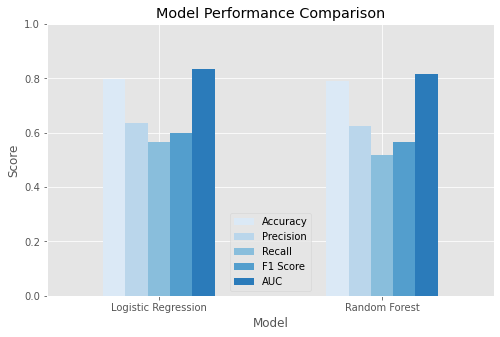

In [80]:
comparison_plot = comparison.set_index("Model")

plt.figure(figsize=(8,5))

comparison_plot.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()

# ✅ Final Remarks

This project demonstrated the complete workflow of a customer churn prediction project, including:

- Data cleaning
- Exploratory Data Analysis
- Feature engineering
- Model training
- Model evaluation
- Business interpretation

The project shows how machine learning can support customer retention strategies by identifying high-risk customers before they leave.